## Sprint 3: Model Architecture, Training, and Evaluation
This notebook covers Sprint 3 of the ASL Language Recognition project. In Sprint 2, the team cleaned the image dataset, created a reproducible train/validation/test split, and built PyTorch DataLoaders for model-ready batches. In Sprint 3, we use those batches to train and evaluate an image classification model.    

Our team uses PyTorch as the deep learning framework for this sprint. The model architecture is based on MobileNetV2 with pretrained ImageNet weights. We apply transfer learning by replacing MobileNetV2’s original 1,000-class classifier with a new classifier that outputs 29 ASL classes. The pretrained layers are frozen first so the model learns the new ASL classifier head before any deeper fine-tuning.    

Team: BeyondWords   
Dataset: ASL Alphabet Language

---
### Load Sprint 2 DataLoader Pipeline

In [48]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


Random seed set to: 42
Cleaned directory exists: True
Cleaned directory path: data/cleaned
Number of folders found: 29
Folders found:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Expected class count: 29
Actual class count: 29
Missing classes: []
Extra classes: []
Total images collected: 87000
Number of classes: 29
Sample record: (PosixPath('data/cleaned/A/A25.jpg'), 0, 'A')
Train samples: 60900
Validation samples: 13050
Test samples: 13050
Total after split: 87000
Train dataset size: 60900
Validation dataset size: 13050
Test dataset size: 13050
Train batches: 1904
Validation batches: 408
Test batches: 408
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


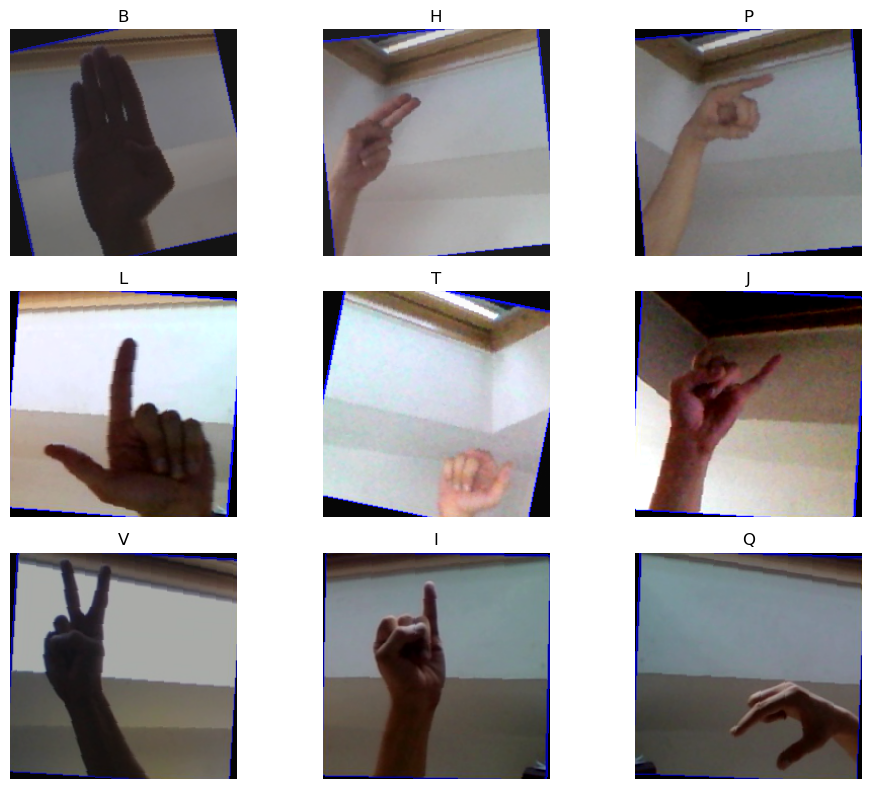

Saved split metadata to: data/asl_dataset_splits.csv
Rows saved: 87000
===== Dataset & DataLoader Verification Summary =====
Cleaned data folder: data/cleaned
Total classes: 29
Total images: 87000

Train images: 60900
Validation images: 13050
Test images: 13050

Batch size: 32
Image size: (224, 224)
Sample batch shape: torch.Size([32, 3, 224, 224])

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Split metadata saved to: data/asl_dataset_splits.csv


In [49]:
# Run the Sprint 2 DataLoader notebook so train_loader, val_loader, and test_loader are available
%run dataset_dataloader_verification.ipynb

In [50]:
# Confirm DataLoaders are now available in this notebook
[name for name in globals().keys() if "loader" in name.lower()]

['__loader__', 'DataLoader', 'train_loader', 'val_loader', 'test_loader']

---
### TASK 1: **Model Architecture**: MobileNetV2 Transfer Learning
This section defines the model architecture for Sprint 3. We use MobileNetV2 with pretrained ImageNet weights as the base CNN because it already learned useful visual features such as edges, shapes, textures, and object parts. Since our task is ASL image classification, we replace the original 1,000-class ImageNet classifier with a new classifier that outputs 29 ASL classes. We freeze the pretrained feature extractor first so the initial training phase only updates the new classifier layer.

#### <u>Important Concepts:</u>
**Transfer learning** allows us to reuse knowledge from a model that was already trained on a large image dataset. **MobileNetV2** already learned general visual patterns such as edges, shapes, textures, and object parts. For this project, we keep that pretrained feature knowledge and replace only the final classification layer so the model can predict our 29 ASL classes instead of ImageNet classes.

**MobileNetV2** was chosen because it is accurate enough for image classification while being lightweight and efficient. This is useful for our ASL recognition project because hand-sign images do not require an extremely large model, and a smaller architecture trains faster. MobileNetV2 uses inverted residual blocks and depthwise separable convolutions, allowing it to learn useful image features with fewer parameters.

**Freezing** means preventing the pretrained layers from changing during the first training phase. We do this because the pretrained MobileNetV2 layers already contain useful general image knowledge. By freezing those layers, the optimizer only updates the new classifier head first. This makes training faster and reduces the risk of overwriting useful pretrained features too early.

---
### Framework Decision: **PyTorch**

For Sprint 3, our team will use PyTorch as the shared deep learning framework. This matches the Sprint 2 pipeline because our Dataset and DataLoader were already built using `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`. PyTorch also gives us direct control over the training loop, model freezing, optimizer setup, and evaluation process.

### Load Pretrained MobileNetV2

In [51]:
import torch
import torch.nn as nn
from torchvision import models

# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load MobileNetV2 with pretrained ImageNet weights
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Move model to selected device
model = model.to(device)

print("MobileNetV2 loaded with pretrained ImageNet weights.")

Using device: cpu
MobileNetV2 loaded with pretrained ImageNet weights.


---
### Replace MobileNetV2 Classifier for 29 ASL Classes

In [52]:
# Number of ASL classes: A-Z plus del, nothing, and space
NUM_CLASSES = 29

# Check the original classifier
print("Original classifier:")
print(model.classifier)

# Get the number of input features going into the final classifier layer
in_features = model.classifier[1].in_features

# Replace the final ImageNet classifier with a new ASL classifier
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

# Move updated model back to device
model = model.to(device)

print("\nUpdated classifier:")
print(model.classifier)
print("\nNumber of output classes:", NUM_CLASSES)

Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Updated classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)

Number of output classes: 29


The original MobileNetV2 classifier was designed to output 1,000 ImageNet classes. Since our ASL dataset has 29 classes, we replaced the final linear layer with a new layer that outputs 29 predictions. Each output corresponds to one ASL class.

---
### Freeze Pretrained Feature Extractor

In [53]:
# Freeze all pretrained layers first
for param in model.features.parameters():
    param.requires_grad = False

# Keep the new classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print("Feature extractor frozen.")
print("Classifier head remains trainable.")

Feature extractor frozen.
Classifier head remains trainable.


In [54]:
frozen_modules = 0
trainable_modules = 0

for name, module in model.named_modules():
    params = list(module.parameters(recurse=False))
    if params:
        if all(not p.requires_grad for p in params):
            frozen_modules += 1
        elif any(p.requires_grad for p in params):
            trainable_modules += 1

print("Frozen modules:", frozen_modules)
print("Trainable modules:", trainable_modules)

Frozen modules: 104
Trainable modules: 1


In [55]:
def count_parameters(model):
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
    frozen_params = total_params - trainable_params
    
    return total_params, trainable_params, frozen_params


total_params, trainable_params, frozen_params = count_parameters(model)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Total parameters: 2261021
Trainable parameters: 37149
Frozen parameters: 2223872


After replacing the classifier, we freeze the pretrained feature extractor by setting `requires_grad = False` for the feature layers. This means those layers will not update during the first training phase. Only the new classifier head remains trainable. This setup allows the model to first learn how to map MobileNetV2’s existing visual features to the 29 ASL classes.

---
### Verify Model Output Shape

In [56]:
# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

# Move images and labels to the same device as the model
images = images.to(device)
labels = labels.to(device)

# Set model to evaluation mode for this shape test
model.eval()

# Disable gradient tracking for this quick check
with torch.no_grad():
    outputs = model(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)
print("Expected output shape:", (images.shape[0], NUM_CLASSES))

Input batch shape: torch.Size([32, 3, 224, 224])
Output batch shape: torch.Size([32, 29])
Expected output shape: (32, 29)


The model successfully accepts one batch from the training DataLoader with shape `[32, 3, 224, 224]`. This means each batch contains 32 RGB images resized to 224 by 224 pixels. The model returns an output shape of `[32, 29]`, which confirms that MobileNetV2 is producing 29 prediction scores for each image. This matches the 29 ASL classes in our dataset, so the model architecture is ready for training.

---
### Verify frozen and trainable parameters

In [57]:
# Count total, trainable, and frozen parameters
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")

Total parameters: 2,261,021
Trainable parameters: 37,149
Frozen parameters: 2,223,872


Most of the MobileNetV2 parameters are frozen because they belong to the pretrained feature extractor. Only the new classifier head remains trainable during the first training phase. This confirms that the optimizer will focus on learning the 29 ASL output classes without changing the pretrained visual feature layers yet.

---
### Define loss function and optimizer

In [58]:
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer will only update trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


We use CrossEntropyLoss because this is a multi-class classification problem where each image belongs to one of 29 ASL classes. We use the Adam optimizer with a learning rate of 0.001 because Adam is commonly used for deep learning and adjusts parameter updates efficiently during training. Since the feature extractor is frozen, the optimizer only updates the new classifier head during the first training phase.

---
### Add a simple one-batch loss test

In [59]:
# Test one forward pass and loss calculation
model.train()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Sample loss:", loss.item())

Output shape: torch.Size([32, 29])
Labels shape: torch.Size([32])
Sample loss: 3.3531529903411865


The one-batch loss test confirms that the model outputs and labels work correctly with CrossEntropyLoss. The model outputs one row of 29 prediction scores per image, while the labels contain one class index per image. Since the loss calculates successfully, the model is ready for the full training loop.

---
### Model Architecture Handoff

The MobileNetV2 transfer learning architecture is ready for training. The model uses pretrained ImageNet weights, the original 1,000-class classifier has been replaced with a new 29-class ASL classifier, and the pretrained feature extractor is frozen. The output shape was verified using one batch from the training DataLoader, and the model returns `[batch_size, 29]` as expected. The loss function and optimizer are also defined, so the training loop can now use `model`, `criterion`, `optimizer`, `train_loader`, and `val_loader`.

# Baseline Training Loop (Owen's Start):

In [60]:
RUN_FULL_TRAINING = False

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
num_epochs = 5

In [62]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

## Creating Hyperparameter Optimization Experiments Table

In [145]:
experiment_log = pd.DataFrame(columns=[
    "Experiment",
    "Learning Rate",
    "Weight Decay",
    "Frozen Layers",
    "Epochs",
    "Train Loss",
    "Train Accuracy",
    "Validation Loss",
    "Final Validation Accuracy",
    "Best Validation Accuracy",
    "Best Epoch",
    "Notes"
])
experiment_log

,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes


## Creating Function for Simpler Training Code (train_model)

In [95]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs, device):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        model.eval()

        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f}"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies

## **Optional Full Training (Full Baseline)**

This cell trains the baseline MobileNetV2 model from scratch. On CPU, a complete run may take many hours. By default, `RUN_FULL_TRAINING` is set to `False` to prevent accidental retraining. Set it, and/or any experimental  training code cell, to `True` only when intentionally training or fine-tuning the model. Use: model.load_state_dict(
    torch.load("../models/baseline_mobilenetv2.pth")
)
in your code for fine-tuning the model.

Baseline validation performance peaked around epoch 4, suggesting longer training may not be necessary without additional optimization.

In [ ]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        num_epochs,
        device
    )

## Baseline Model Results

Architecture: MobileNetV2
Transfer Learning: Feature extractor frozen
Trainable Parameters: 37,149
Frozen Parameters: 2,223,872

Epoch Results:

| Epoch | Train Loss | Train Acc | Val Loss | Val Acc |
|------|-----------|-----------|----------|---------|
|1|0.6153|81.84%|0.4392|88.85%|
|2|0.5645|82.57%|0.3955|88.80%|
|3|0.5409|83.00%|0.3639|89.75%|
|4|0.5138|83.79%|0.3230|91.03%|
|5|0.5127|83.59%|0.3259|90.75%|

Observations:
- Validation accuracy improved steadily through epoch 4.
- Validation loss decreased consistently before leveling off.
- Slight decrease in validation accuracy at epoch 5 may indicate diminishing returns.

In [190]:
import matplotlib.pyplot as plt

if RUN_FULL_TRAINING:
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()
else:
    print("Plot skipped because full training was not run.")

Plot skipped because full training was not run.


In [191]:

if RUN_FULL_TRAINING:
    plt.figure()
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.show()
else:
    print("Plot skipped because full training was not run.")

Plot skipped because full training was not run.


In [ ]:
import os

if RUN_FULL_TRAINING:
    os.makedirs("../models", exist_ok=True)
    torch.save(
        model.state_dict(),
        "../models/baseline_mobilenetv2.pth"
    )
    print("Baseline model saved successfully!")

Baseline model saved successfully!


In [96]:
NUM_CLASSES = 29

#Creating function for fresh MobileNetV2, from before Baseline 1 for future experiments

def create_model():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    # Freezing pretrained feature extractor
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier for ASL classes
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    # Keep classifier trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model.to(device)

In [146]:
experiment_log.loc[len(experiment_log)] = [
    "Baseline (5 Epochs)",
    0.001,
    0,
    "Features Frozen",
    5,
    0.5127,
    round(0.8359 * 100, 2),
    0.3259,
    round(0.9075 * 100, 2),
    round(0.9103 * 100, 2),
    4,
    "Original baseline. Validation accuracy peaked at Epoch 4."
]

experiment_log

,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes
0,Baseline (5 Epochs),0.001,0,Features Frozen,5,0.5127,83.59,0.3259,90.75,91.03,4,Original baseline. Validation accuracy peaked ...


## Experiment 1: Quick Baseline (2 Epochs)

**Purpose:** Create a short baseline from a fresh pretrained MobileNetV2 to serve as the reference for optimization experiments.

**Changes from Full Baseline:**
- Epochs reduced from 5 to 2.
- All other hyperparameters remain unchanged.

In [ ]:
# -------------------------
# Experiment: Quick Baseline
# -------------------------

RUN_EXPERIMENTAL_BASELINE = False

if RUN_EXPERIMENTAL_BASELINE:

    model = create_model()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=0.001
    )

    num_epochs = 2

    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=2,
        device=device
    )

Epoch 1/2 | Train Loss: 1.3033 | Train Acc: 0.6907 | Val Loss: 0.7085 | Val Acc: 0.8364
Epoch 2/2 | Train Loss: 0.7146 | Train Acc: 0.8003 | Val Loss: 0.5195 | Val Acc: 0.8706


In [ ]:
if RUN_EXPERIMENTAL_BASELINE:
    quick_baseline_results = {
        "train_loss": train_losses[-1],
        "train_acc": train_accuracies[-1],
        "val_loss": val_losses[-1],
        "val_acc": val_accuracies[-1],
        "best_val_acc": max(val_accuracies),
        "best_epoch": val_accuracies.index(max(val_accuracies)) + 1
    }

In [150]:
experiment_log.loc[1] = [
    "Experimental Baseline (2 Epochs)",
    0.001,
    0,
    "Features Frozen",
    2,
    0.7146,
    80.03,
    0.5195,
    87.06,
    87.06,
    2,
    "Fresh pretrained MobileNetV2 used as optimization baseline."
]

experiment_log

,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes
0,Baseline (5 Epochs),0.001,0,Features Frozen,5,0.5127,83.59,0.3259,90.75,91.03,4,Original baseline. Validation accuracy peaked ...
1,Experimental Baseline (2 Epochs),0.001,0,Features Frozen,2,0.7146,80.03,0.5195,87.06,87.06,2,Fresh pretrained MobileNetV2 used as optimizat...


## Experiment 2: Lower Learning Rate

**Purpose:** Evaluate whether a smaller learning rate improves validation performance.

**Changes from Quick Baseline:**
- Learning rate: 0.001 → 0.0001
- All other settings unchanged.

In [ ]:
# -------------------------
# Experiment: Lower Learning Rate
# -------------------------

RUN_LOWER_LR = False

if RUN_LOWER_LR:

    model = create_model()

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=0.0001
    )

    num_epochs = 2

    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=2,
        device=device
    )

Epoch 1/2 | Train Loss: 2.6559 | Train Acc: 0.4646 | Val Loss: 2.1746 | Val Acc: 0.6636
Epoch 2/2 | Train Loss: 1.8264 | Train Acc: 0.6704 | Val Loss: 1.6267 | Val Acc: 0.7325


In [ ]:
# -------------------------
# Experiment: Increase to 3 Epochs
# -------------------------

RUN_THREE_EPOCHS = False

if RUN_THREE_EPOCHS:

    model = create_model()
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=0.001
    )

    num_epochs = 3

    train_losses, val_losses, train_accuracies, val_accuracies = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        num_epochs=num_epochs,
        device=device
    )

Epoch 1/3 | Train Loss: 1.3045 | Train Acc: 0.6898 | Val Loss: 0.7727 | Val Acc: 0.8211
Epoch 2/3 | Train Loss: 0.7116 | Train Acc: 0.8008 | Val Loss: 0.5141 | Val Acc: 0.8743
Epoch 3/3 | Train Loss: 0.6076 | Train Acc: 0.8183 | Val Loss: 0.4360 | Val Acc: 0.8850


## Experiment Summary

The following experiments evaluate different optimization strategies for the MobileNetV2 ASL classifier. Each experiment begins from a fresh pretrained MobileNetV2 model to ensure a fair comparison. Unless otherwise noted, the feature extractor remains frozen and only the classifier head is trained.

The goal of these experiments is to identify which training configuration provides the strongest validation performance while remaining computationally practical.

In [ ]:
completed_results = [
    [
        "Lower LR",
        0.0001,
        0,
        "Features Frozen",
        2,
        1.8264,
        67.04,
        1.6267,
        73.25,
        73.25,
        2,
        "Lower learning rate slowed convergence."
    ],
    [
        "3-Epochs",
        0.001,
        0,
        "Features Frozen",
        3,
        0.6076,
        81.83,
        0.4360,
        88.50,
        88.50,
        3,
        "One additional epoch improved performance."
    ]
]

for result in completed_results:
    experiment_log.loc[len(experiment_log)] = result

experiment_log = experiment_log.drop_duplicates(
    subset=["Experiment"],
    keep="last"
).reset_index(drop=True)

experiment_log

In [165]:
experiment_log.style.format({
    "Learning Rate": "{:.4f}",
    "Weight Decay": "{:.0e}",
    "Train Loss": "{:.4f}",
    "Validation Loss": "{:.4f}",
    "Train Accuracy": "{:.2f}%",
    "Final Validation Accuracy": "{:.2f}%",
    "Best Validation Accuracy": "{:.2f}%"
})

,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes
0,Baseline (5 Epochs),0.0010,0e+00,Features Frozen,5,0.5127,83.59%,0.3259,90.75%,91.03%,4,Original baseline. Validation accuracy peaked at Epoch 4.
1,Experimental Baseline (2 Epochs),0.0010,0e+00,Features Frozen,2,0.7146,80.03%,0.5195,87.06%,87.06%,2,Fresh pretrained MobileNetV2 used as optimization baseline.
2,Lower LR,0.0001,0e+00,Features Frozen,2,1.8264,67.04%,1.6267,73.25%,73.25%,2,Lower learning rate slowed convergence and reduced validation accuracy under the 2-epoch training budget.
3,3-Epochs,0.0010,0e+00,Features Frozen,3,0.6076,81.83%,0.4360,88.50%,88.50%,3,Tested whether one additional epoch improved performance without changing other settings.


/var/folders/zb/5xl8h6kd4qx7z31q22wddc840000gn/T/ipykernel_34948/4001547232.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experiment_log.loc[len(experiment_log)] = result


,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes
0,Baseline (5 Epochs),0.0010,0,Features Frozen,5,0.5127,83.59,0.3259,90.75,91.03,4,Original baseline. Validation accuracy peaked ...
1,Experimental Baseline (2 Epochs),0.0010,0,Features Frozen,2,0.7146,80.03,0.5195,87.06,87.06,2,Fresh pretrained MobileNetV2 used as optimizat...
2,Lower LR,0.0001,0,Features Frozen,2,1.8264,67.04,1.6267,73.25,73.25,2,Lower learning rate slowed convergence.
3,3-Epochs,0.0010,0,Features Frozen,3,0.6076,81.83,0.4360,88.50,88.50,3,One additional epoch improved performance.


## Observations

- The 5-epoch baseline achieved the strongest overall validation accuracy.
- The 2-epoch experimental baseline provided a useful reference for rapid experimentation.
- Reducing the learning rate from 0.001 to 0.0001 substantially slowed convergence and reduced validation accuracy.
- Additional experiments explore the trade-off between training time and predictive performance.

In [189]:
experiment_summary = experiment_log.sort_values(
    by="Final Validation Accuracy",
    ascending=False
)

experiment_summary

,Experiment,Learning Rate,Weight Decay,Frozen Layers,Epochs,Train Loss,Train Accuracy,Validation Loss,Final Validation Accuracy,Best Validation Accuracy,Best Epoch,Notes
0,Baseline (5 Epochs),0.0010,0,Features Frozen,5,0.5127,83.59,0.3259,90.75,91.03,4,Original baseline. Validation accuracy peaked ...
3,3-Epochs,0.0010,0,Features Frozen,3,0.6076,81.83,0.4360,88.50,88.50,3,One additional epoch improved performance.
1,Experimental Baseline (2 Epochs),0.0010,0,Features Frozen,2,0.7146,80.03,0.5195,87.06,87.06,2,Fresh pretrained MobileNetV2 used as optimizat...
2,Lower LR,0.0001,0,Features Frozen,2,1.8264,67.04,1.6267,73.25,73.25,2,Lower learning rate slowed convergence.


## Plots

### Final Validation Accuracy by Experiment

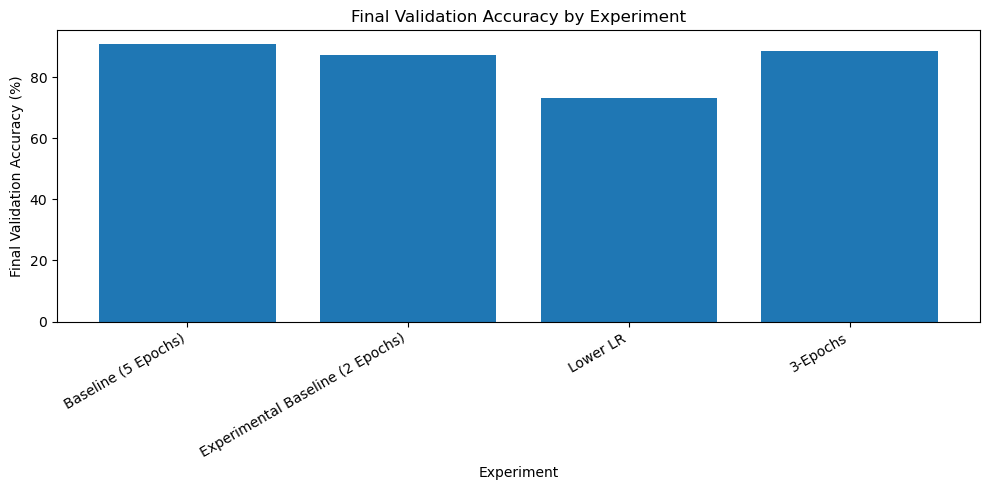

In [167]:
plt.figure(figsize=(10, 5))
plt.bar(
    experiment_log["Experiment"],
    experiment_log["Final Validation Accuracy"]
)
plt.xlabel("Experiment")
plt.ylabel("Final Validation Accuracy (%)")
plt.title("Final Validation Accuracy by Experiment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The original five-epoch baseline achieved the highest validation accuracy (90.75%), indicating that additional training epochs improved performance. The two-epoch experimental baseline provided competitive results while significantly reducing training time. Lowering the learning rate to 0.0001 substantially reduced validation accuracy, suggesting slower convergence under the limited training budget.

### Final Validation Loss by Experiment

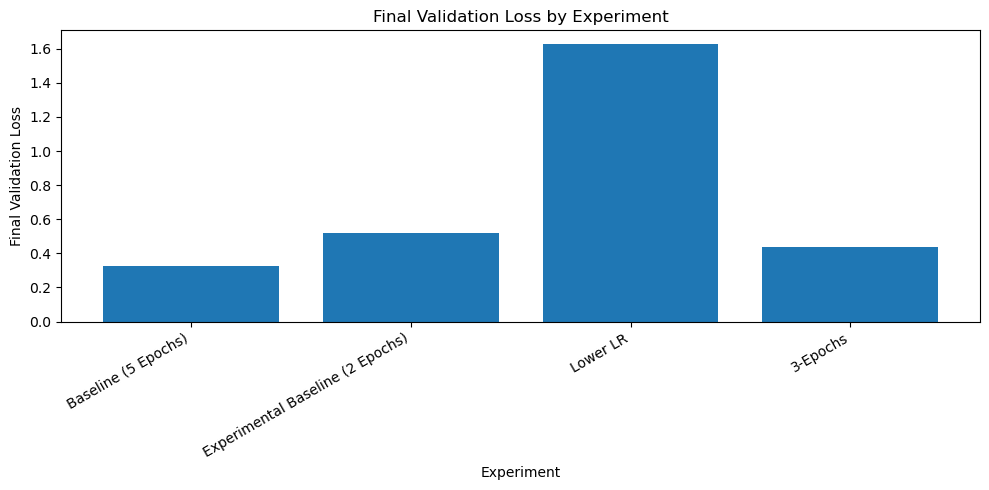

In [169]:
plt.figure(figsize=(10, 5))
plt.bar(
    experiment_log["Experiment"],
    experiment_log["Validation Loss"]
)
plt.xlabel("Experiment")
plt.ylabel("Final Validation Loss")
plt.title("Final Validation Loss by Experiment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Validation loss generally decreased as training progressed, indicating improved model generalization. The lower learning rate experiment produced substantially higher validation loss, supporting the conclusion that the model had not sufficiently converged within two epochs.

### Full Baseline Loss Curve

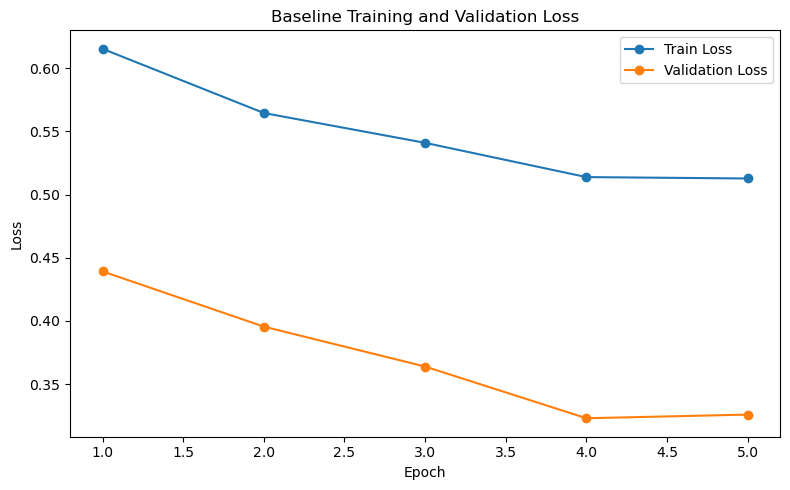

In [170]:
baseline_train_losses = [0.6153, 0.5645, 0.5409, 0.5138, 0.5127]
baseline_val_losses = [0.4392, 0.3955, 0.3639, 0.3230, 0.3259]

epochs = range(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_train_losses, marker="o", label="Train Loss")
plt.plot(epochs, baseline_val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Both training and validation loss decreased consistently over the five training epochs. The relatively small gap between the two curves suggests that the model learned effectively without severe overfitting during baseline training.

### Full Baseline Accuracy Curve

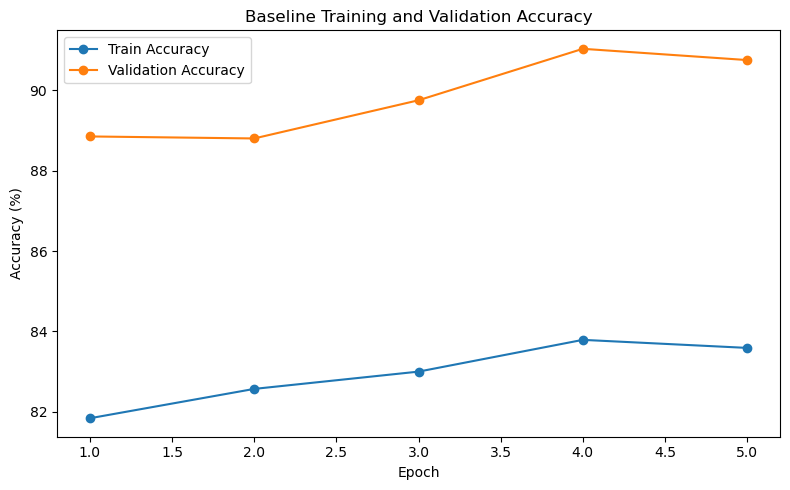

In [171]:
baseline_train_acc = [81.84, 82.57, 83.00, 83.79, 83.59]
baseline_val_acc = [88.85, 88.80, 89.75, 91.03, 90.75]

plt.figure(figsize=(8, 5))
plt.plot(epochs, baseline_train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, baseline_val_acc, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Training and validation accuracy increased steadily throughout training. Validation accuracy peaked during the fourth epoch before stabilizing, suggesting that the model approached convergence after several epochs.

# Optimization Summary

Four training configurations were evaluated during Sprint 3. The original five-epoch baseline achieved the highest validation accuracy (90.75%), while the two-epoch baseline provided a computationally efficient alternative for rapid experimentation. Lowering the learning rate to 0.0001 significantly reduced convergence speed and overall performance. Extending the training duration demonstrated that additional epochs generally improved model performance, supporting the selection of the original learning rate and frozen-feature transfer learning strategy for the final model.

# Final Model Evaluation

The final selected MobileNetV2 model was evaluated on the held-out test dataset. Performance was measured using classification accuracy, precision, recall, F1-score, and a confusion matrix to assess classification performance across all 29 ASL classes.

In [174]:
model = create_model()

model.load_state_dict(
    torch.load("../models/baseline_mobilenetv2.pth", map_location=device)
)

model.to(device)
model.eval()

print("5-epoch baseline model loaded successfully!")

5-epoch baseline model loaded successfully!


In [175]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

### Accuracy

In [176]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9069


### Model Performance Interpretation
The final 5-epoch MobileNetV2 baseline achieved a test accuracy of 90.69%, which is very close to the best validation accuracy of 91.03% and final validation accuracy of 90.75%. This suggests the model generalized well to the held-out test set and did not show a major train/validation/test performance gap. Since the feature extractor was frozen and only the classifier head was trained, this is a strong baseline result for transfer learning.
The classification report also shows balanced overall performance, with macro and weighted averages around 0.91. Because each class has the same test support of 450 images, the macro average is especially useful here: it confirms that the model is not simply performing well because of class imbalance.

### Precision, Recall, and F1-score

In [179]:
class_names = [
    "A","B","C","D","E","F","G","H","I","J","K","L","M",
    "N","O","P","Q","R","S","T","U","V","W","X","Y","Z",
    "del","nothing","space"
]

In [181]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

           A       0.85      0.96      0.90       450
           B       0.96      0.93      0.95       450
           C       0.95      0.97      0.96       450
           D       0.90      0.98      0.94       450
           E       0.91      0.82      0.86       450
           F       0.99      0.94      0.97       450
           G       0.91      0.89      0.90       450
           H       0.95      0.93      0.94       450
           I       0.95      0.79      0.86       450
           J       0.93      0.88      0.90       450
           K       0.93      0.88      0.90       450
           L       0.98      0.94      0.96       450
           M       0.95      0.81      0.87       450
           N       0.85      0.94      0.90       450
           O       0.97      0.97      0.97       450
           P       0.97      0.97      0.97       450
           Q       0.98      0.96      0.97       450
           R       0.91    

### Experiment Interpretation
The 5-epoch baseline was the strongest experiment overall.
Increasing training from 2 to 3 epochs improved validation performance, showing that the classifier head benefited from additional training time. The lower learning rate experiment performed much worse, suggesting that lr=0.0001 was too small for the frozen-feature setup under a short training budget. The model likely learned too slowly when only the classifier head was trainable.

### Confusion Matrix

In [184]:
from sklearn.metrics import ConfusionMatrixDisplay

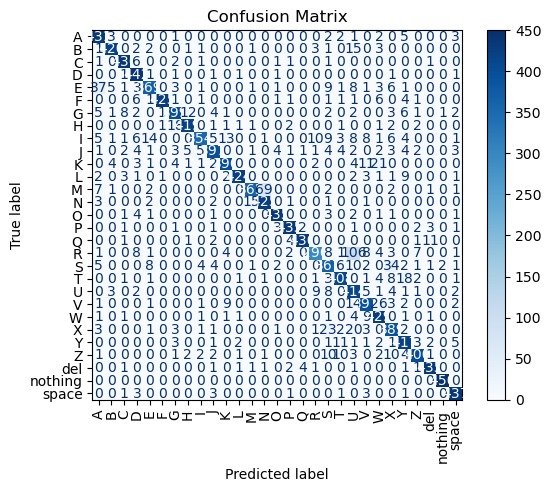

In [186]:

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

### Re-sizing for Better Visibility

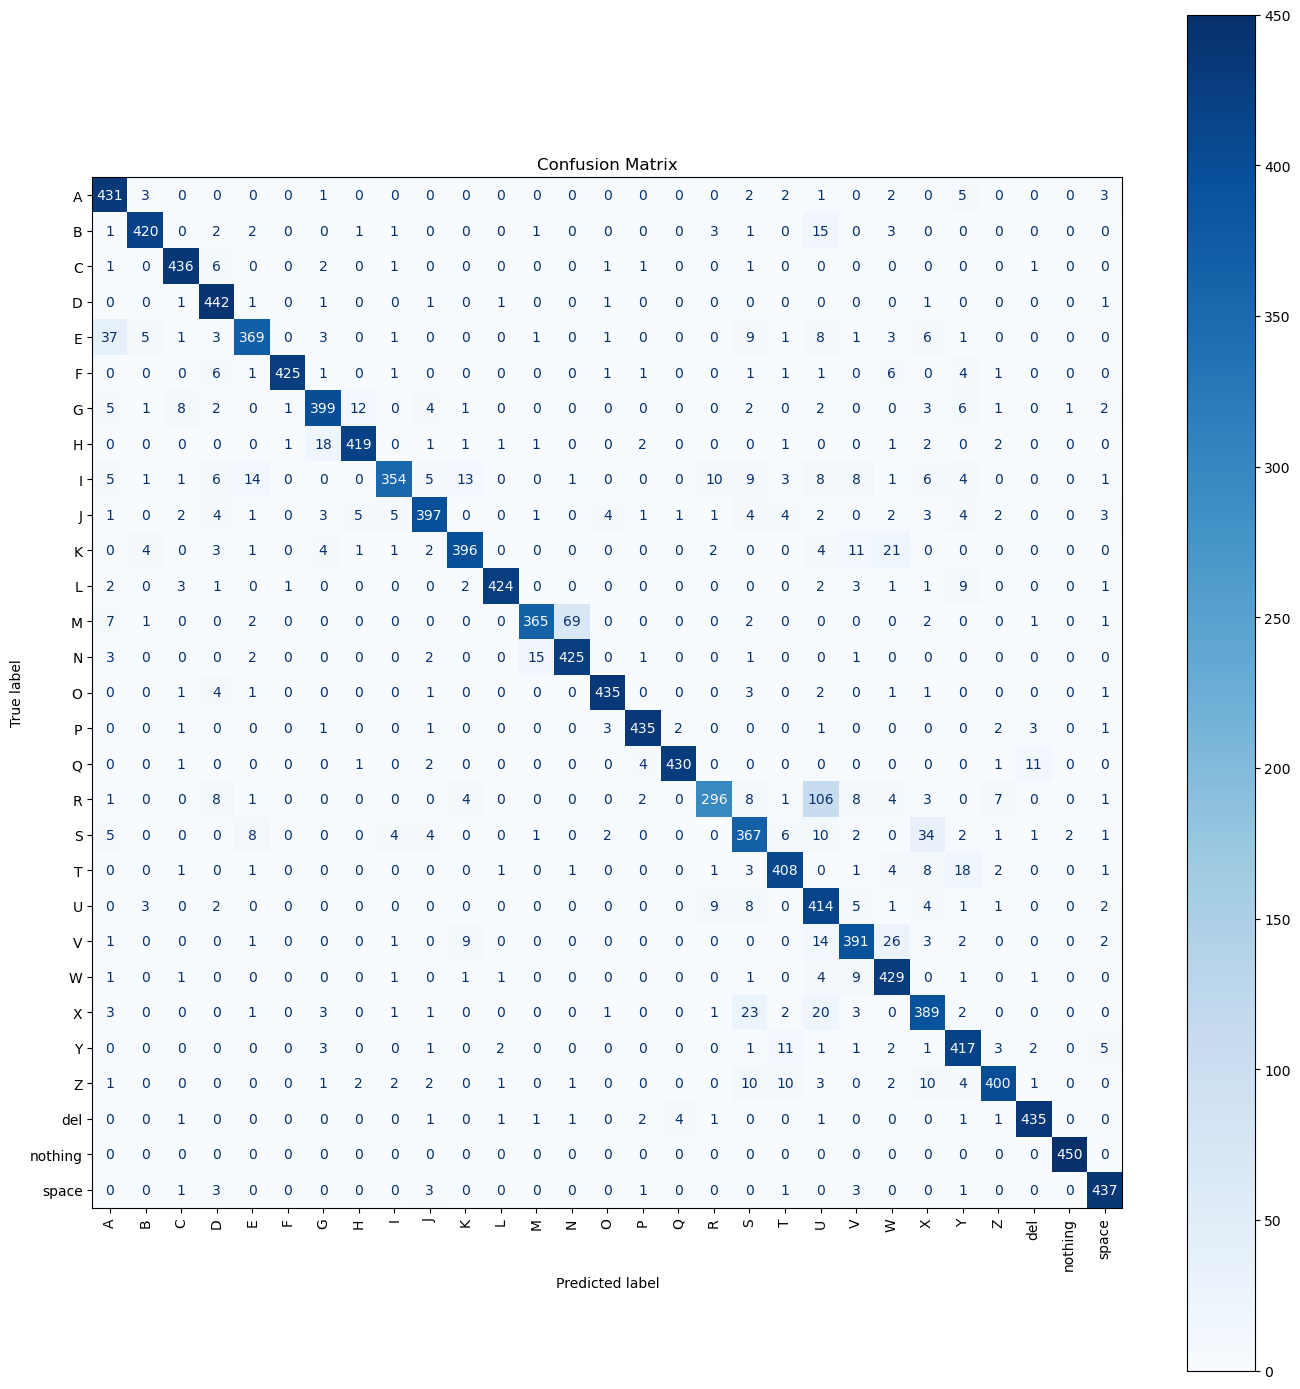

In [187]:

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation
The confusion matrix shows strong diagonal performance overall, meaning most images were classified correctly. Some classes were especially strong, including nothing, which had 450/450 correct, and several classes such as O, P, Q, and F, which had high precision and recall.
The main weaknesses appear in visually similar hand signs, such as the letter R being confused with U, M as opposed to N, S when compared to X, and other cases that are likely to result in low recall. These errors stem from more subtle details in gesturing, like finger positioning and smaller shape definition problems. The model can identify accurate matches in large strokes, but the miniscule details of a given image are still capable of leading the model astray with its findings.

### Conclusion
Overall, the frozen MobileNetV2 model provides a strong baseline. The test accuracy of 90.69% shows that transfer learning worked well for this ASL alphabet classification task. The next improvements should focus on reducing confusion between visually similar signs, especially R/U, M/N, S/X, and V/W. Potential next steps include fine-tuning the last MobileNetV2 block, reviewing augmentation choices, or adding targeted analysis of the most confused classes.